In [1]:
!mamba install pandas numpy matplotlib seaborn

!mamba install scikit-learn

mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 6.386 seconds
  Name           Version  Build                Channel
--------------------------------------------------------------------
+ pandas         3.0.5    np23py313h1e705a5_0  emscripten-forge-4x
+ patsy          1.0.2    py313h1804a44_3      emscripten-forge-4x
+ python-tzdata  2026.3   pyhd8ed1ab_0         conda-forge
+ seaborn        0.13.2   hd8ed1ab_3           conda-forge
+ seaborn-base   0.13.2   pyhd8ed1ab_3         conda-forge
+ statsmodels    0.14.6   np23py313hd8db738_2  emscripten-forge-4x
- pip            26.1.2   pyh145f28c_0         conda-forge
mambajs 0.21.4

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge-4x, conda-forge

Solving environment...
Solving took 1.843 seconds
  N

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report
)

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "MALE_UAV_aero_piston_engine_final_100k.csv"
)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (100000, 34)


,timestamp_s,engine_id,mission_id,mission_type,altitude_m,ambient_temp_C,pressure_kPa,air_density_kg_m3,throttle_pct,load_pct,...,expected_rpm,expected_cht_C,expected_egt_C,physics_residual_C,health_index,fault_type,fault_severity,degradation,failure_flag,rul_hours
0,0,ENGINE_001,1,normal_isr,15.24,25.00,100.726,1.17692,70.0,70.75,...,2307.45,134.10,673.08,-1.21,97.31,normal,0.0,0.0,0,NaN
1,1,ENGINE_001,1,normal_isr,30.48,25.01,100.129,1.16992,70.0,69.79,...,2297.93,132.69,669.38,-0.04,97.31,normal,0.0,0.0,0,NaN
2,2,ENGINE_001,1,normal_isr,45.72,25.02,99.536,1.16296,70.0,70.97,...,2309.72,134.62,674.20,0.03,97.28,normal,0.0,0.0,0,NaN
3,3,ENGINE_001,1,normal_isr,60.96,25.02,98.945,1.15602,70.0,72.28,...,2322.85,136.77,679.56,0.66,97.50,normal,0.0,0.0,0,NaN
4,4,ENGINE_001,1,normal_isr,76.20,25.03,98.358,1.14912,70.0,69.65,...,2296.49,132.71,669.12,-1.91,97.40,normal,0.0,0.0,0,NaN


In [4]:
print("Number of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
missing_values = df.isna().sum()
print(missing_values[missing_values > 0])

print("\nNumber of unique missions:", df["mission_id"].nunique())
print("Number of unique engines:", df["engine_id"].nunique())

print("\nFault distribution:")
print(df["fault_type"].value_counts())

print("\nFault distribution (%):")
print(
    df["fault_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Number of rows: 100000
Number of columns: 34

Column names:
['timestamp_s', 'engine_id', 'mission_id', 'mission_type', 'altitude_m', 'ambient_temp_C', 'pressure_kPa', 'air_density_kg_m3', 'throttle_pct', 'load_pct', 'rpm', 'air_mass_flow_kg_s', 'fuel_flow_kg_s', 'torque_Nm', 'power_W', 'cht_C', 'egt_C', 'oil_temperature_C', 'oil_pressure_bar', 'vibration_rms', 'battery_voltage_V', 'alternator_current_A', 'alternator_health', 'injection_timing_deg', 'expected_rpm', 'expected_cht_C', 'expected_egt_C', 'physics_residual_C', 'health_index', 'fault_type', 'fault_severity', 'degradation', 'failure_flag', 'rul_hours']

Data types:
timestamp_s               int64
engine_id                   str
mission_id                int64
mission_type                str
altitude_m              float64
ambient_temp_C          float64
pressure_kPa            float64
air_density_kg_m3       float64
throttle_pct            float64
load_pct                float64
rpm                     float64
air_mass_flow_kg

In [5]:
mission_fault_summary = (
    df.groupby(["mission_id", "fault_type"])
      .size()
      .reset_index(name="samples")
      .sort_values(["mission_id", "fault_type"])
)

print(mission_fault_summary.to_string(index=False))

 mission_id              fault_type  samples
          1                  normal     1000
          2                  normal     1000
          3                  normal     1000
          4                  normal     1000
          5                  normal     1000
          6                  normal     1000
          7                  normal     1000
          8                  normal     1000
          9                  normal     1000
         10                  normal     1000
         11                  normal     1000
         12                  normal     1000
         13                  normal     1000
         14                  normal     1000
         15                  normal     1000
         16                  normal     1000
         17                  normal     1000
         18                  normal     1000
         19                  normal     1000
         20                  normal     1000
         21                  normal     1000
         2

In [6]:
mission_fault_counts = (
    mission_fault_summary
    .groupby("mission_id")["fault_type"]
    .nunique()
)

mixed_missions = mission_fault_counts[mission_fault_counts > 1]

print("\nNumber of missions containing multiple fault labels:",
      len(mixed_missions))

print("\nMixed missions:")
print(mixed_missions)


Number of missions containing multiple fault labels: 30

Mixed missions:
mission_id
71     2
72     2
73     2
74     2
75     2
76     2
77     2
78     2
79     2
80     2
81     2
82     2
83     2
84     2
85     2
86     2
87     2
88     2
89     2
90     2
91     2
92     2
93     2
94     2
95     2
96     2
97     2
98     2
99     2
100    2
Name: fault_type, dtype: int64


In [7]:
print("\nDetailed mixed-mission structure:")

for mission_id in mixed_missions.index:
    mission_rows = mission_fault_summary[
        mission_fault_summary["mission_id"] == mission_id
    ]

    print(
        f"\nMission {mission_id}:"
    )
    print(
        mission_rows[
            ["mission_id", "fault_type", "samples"]
        ].to_string(index=False)
    )


Detailed mixed-mission structure:

Mission 71:
 mission_id           fault_type  samples
         71 injector_degradation      854
         71               normal      146

Mission 72:
 mission_id           fault_type  samples
         72 injector_degradation      854
         72               normal      146

Mission 73:
 mission_id           fault_type  samples
         73 injector_degradation      854
         73               normal      146

Mission 74:
 mission_id           fault_type  samples
         74 injector_degradation      854
         74               normal      146

Mission 75:
 mission_id           fault_type  samples
         75 injector_degradation      854
         75               normal      146

Mission 76:
 mission_id           fault_type  samples
         76 injector_degradation      854
         76               normal      146

Mission 77:
 mission_id           fault_type  samples
         77 injector_degradation      854
         77               normal  

In [8]:
df["anomaly_label"] = (
    df["fault_type"] != "normal"
).astype(int)

print("Anomaly label distribution:")
print(df["anomaly_label"].value_counts())

print("\nAnomaly label percentages:")
print(
    df["anomaly_label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Anomaly label distribution:
anomaly_label
0    75753
1    24247
Name: count, dtype: int64

Anomaly label percentages:
anomaly_label
0    75.75
1    24.25
Name: proportion, dtype: float64


In [9]:
df["cht_residual"] = (
    df["cht_C"] - df["expected_cht_C"]
)

df["egt_residual"] = (
    df["egt_C"] - df["expected_egt_C"]
)

df["rpm_residual"] = (
    df["rpm"] - df["expected_rpm"]
)

In [10]:
feature_cols = [
    "cht_C",
    "egt_C",
    "oil_temperature_C",
    "oil_pressure_bar",
    "vibration_rms",
    "battery_voltage_V",
    "alternator_current_A",
    "alternator_health",
    "injection_timing_deg",
    "cht_residual",
    "egt_residual",
    "rpm_residual",
    "physics_residual_C"
]

In [11]:
print("Isolation Forest feature columns:")
for i, feature in enumerate(feature_cols, start=1):
    print(f"{i:02d}. {feature}")

Isolation Forest feature columns:
01. cht_C
02. egt_C
03. oil_temperature_C
04. oil_pressure_bar
05. vibration_rms
06. battery_voltage_V
07. alternator_current_A
08. alternator_health
09. injection_timing_deg
10. cht_residual
11. egt_residual
12. rpm_residual
13. physics_residual_C


In [12]:
feature_missing = df[feature_cols].isna().sum()

print("\nMissing values in model features:")
print(feature_missing)

if feature_missing.sum() == 0:
    print("\nPASS: No missing values in model features.")
else:
    print("\nWARNING: Missing values exist in model features.")


Missing values in model features:
cht_C                   0
egt_C                   0
oil_temperature_C       0
oil_pressure_bar        0
vibration_rms           0
battery_voltage_V       0
alternator_current_A    0
alternator_health       0
injection_timing_deg    0
cht_residual            0
egt_residual            0
rpm_residual            0
physics_residual_C      0
dtype: int64

PASS: No missing values in model features.


In [13]:
mission_fault_types = (
    df.groupby("mission_id")["fault_type"]
      .apply(lambda x: set(x))
)

healthy_missions = sorted([
    mission_id
    for mission_id, fault_types in mission_fault_types.items()
    if fault_types == {"normal"}
])

fault_missions = sorted([
    mission_id
    for mission_id, fault_types in mission_fault_types.items()
    if fault_types != {"normal"}
])

print("Healthy missions:", len(healthy_missions))
print("Fault-containing missions:", len(fault_missions))

print("\nHealthy mission IDs:")
print(healthy_missions)

print("\nFault-containing mission IDs:")
print(fault_missions)

Healthy missions: 70
Fault-containing missions: 30

Healthy mission IDs:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70]

Fault-containing mission IDs:
[71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


In [14]:
fault_mission_type = (
    df[df["fault_type"] != "normal"]
    .groupby("mission_id")["fault_type"]
    .first()
    .to_dict()
)

print("\nFault mission mapping:")

for mission_id in sorted(fault_mission_type):
    print(
        mission_id,
        "->",
        fault_mission_type[mission_id]
    )


Fault mission mapping:
71 -> injector_degradation
72 -> injector_degradation
73 -> injector_degradation
74 -> injector_degradation
75 -> injector_degradation
76 -> injector_degradation
77 -> injector_degradation
78 -> injector_degradation
79 -> injector_degradation
80 -> injector_degradation
81 -> lubrication_degradation
82 -> lubrication_degradation
83 -> lubrication_degradation
84 -> lubrication_degradation
85 -> lubrication_degradation
86 -> lubrication_degradation
87 -> lubrication_degradation
88 -> lubrication_degradation
89 -> overheating
90 -> overheating
91 -> overheating
92 -> overheating
93 -> overheating
94 -> misfire
95 -> misfire
96 -> misfire
97 -> misfire
98 -> sensor_fault
99 -> sensor_fault
100 -> sensor_fault


In [15]:
fault_mission_df = pd.DataFrame({
    "mission_id": list(fault_mission_type.keys()),
    "fault_type": list(fault_mission_type.values())
})

print("\nFault missions by category:")
print(
    fault_mission_df["fault_type"]
    .value_counts()
)


Fault missions by category:
fault_type
injector_degradation       10
lubrication_degradation     8
overheating                 5
misfire                     4
sensor_fault                3
Name: count, dtype: int64


In [16]:
healthy_train_missions, healthy_temp_missions = train_test_split(
    healthy_missions,
    test_size=0.40,
    random_state=42
)

healthy_val_missions, healthy_test_missions = train_test_split(
    healthy_temp_missions,
    test_size=0.50,
    random_state=42
)

In [17]:
fault_train_missions = []
fault_val_missions = []
fault_test_missions = []

for fault_type in sorted(fault_mission_df["fault_type"].unique()):

    missions_for_fault = (
        fault_mission_df[
            fault_mission_df["fault_type"] == fault_type
        ]["mission_id"]
        .tolist()
    )

    missions_for_fault = sorted(missions_for_fault)

    train_fault, temp_fault = train_test_split(
        missions_for_fault,
        test_size=0.40,
        random_state=42
    )

    val_fault, test_fault = train_test_split(
        temp_fault,
        test_size=0.50,
        random_state=42
    )

    fault_train_missions.extend(train_fault)
    fault_val_missions.extend(val_fault)
    fault_test_missions.extend(test_fault)

In [18]:
fault_train_missions = sorted(fault_train_missions)
fault_val_missions = sorted(fault_val_missions)
fault_test_missions = sorted(fault_test_missions)

In [19]:
train_missions = sorted(
    healthy_train_missions + fault_train_missions
)

val_missions = sorted(
    healthy_val_missions + fault_val_missions
)

test_missions = sorted(
    healthy_test_missions + fault_test_missions
)

In [20]:
train_set = set(train_missions)
val_set = set(val_missions)
test_set = set(test_missions)

print("Train missions:", len(train_set))
print("Validation missions:", len(val_set))
print("Test missions:", len(test_set))

print("\nTrain ∩ Validation:")
print(train_set.intersection(val_set))

print("\nTrain ∩ Test:")
print(train_set.intersection(test_set))

print("\nValidation ∩ Test:")
print(val_set.intersection(test_set))

Train missions: 58
Validation missions: 21
Test missions: 21

Train ∩ Validation:
set()

Train ∩ Test:
set()

Validation ∩ Test:
set()


In [21]:
all_split_missions = train_set | val_set | test_set

print("\nTotal unique missions across all splits:",
      len(all_split_missions))

print("Expected total missions:",
      df["mission_id"].nunique())

if len(all_split_missions) == df["mission_id"].nunique():
    print("PASS: Every mission belongs to exactly one split.")
else:
    print("ERROR: Mission split is incomplete.")


Total unique missions across all splits: 100
Expected total missions: 100
PASS: Every mission belongs to exactly one split.


In [22]:
def mission_category_summary(mission_ids):
    rows = []

    for mission_id in mission_ids:
        if mission_id in fault_mission_type:
            category = fault_mission_type[mission_id]
        else:
            category = "normal"

        rows.append({
            "mission_id": mission_id,
            "category": category
        })

    return pd.DataFrame(rows)


train_mission_summary = mission_category_summary(train_missions)
val_mission_summary = mission_category_summary(val_missions)
test_mission_summary = mission_category_summary(test_missions)

print("\n========== TRAIN MISSION DISTRIBUTION ==========")
print(train_mission_summary["category"].value_counts())

print("\n========== VALIDATION MISSION DISTRIBUTION ==========")
print(val_mission_summary["category"].value_counts())

print("\n========== TEST MISSION DISTRIBUTION ==========")
print(test_mission_summary["category"].value_counts())


========== TRAIN MISSION DISTRIBUTION ==========
category
normal                     42
injector_degradation        6
lubrication_degradation     4
overheating                 3
misfire                     2
sensor_fault                1
Name: count, dtype: int64

========== VALIDATION MISSION DISTRIBUTION ==========
category
normal                     14
injector_degradation        2
lubrication_degradation     2
overheating                 1
misfire                     1
sensor_fault                1
Name: count, dtype: int64

========== TEST MISSION DISTRIBUTION ==========
category
normal                     14
injector_degradation        2
lubrication_degradation     2
overheating                 1
misfire                     1
sensor_fault                1
Name: count, dtype: int64


In [23]:
print("\n========== TRAIN MISSION IDS ==========")
print(train_missions)

print("\n========== VALIDATION MISSION IDS ==========")
print(val_missions)

print("\n========== TEST MISSION IDS ==========")
print(test_missions)


========== TRAIN MISSION IDS ==========
[2, 3, 4, 7, 9, 12, 14, 15, 16, 18, 20, 21, 22, 24, 25, 26, 27, 28, 30, 33, 37, 38, 39, 40, 42, 44, 47, 49, 51, 52, 53, 56, 57, 60, 61, 62, 64, 65, 66, 67, 69, 70, 73, 74, 75, 77, 78, 80, 83, 84, 85, 87, 89, 91, 92, 94, 96, 100]

========== VALIDATION MISSION IDS ==========
[5, 8, 11, 17, 29, 32, 34, 41, 45, 48, 50, 58, 59, 63, 76, 79, 81, 82, 90, 95, 98]

========== TEST MISSION IDS ==========
[1, 6, 10, 13, 19, 23, 31, 35, 36, 43, 46, 54, 55, 68, 71, 72, 86, 88, 93, 97, 99]


In [24]:
train_df = df[df["mission_id"].isin(train_missions)].copy()
val_df = df[df["mission_id"].isin(val_missions)].copy()
test_df = df[df["mission_id"].isin(test_missions)].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (58000, 38)
Validation shape: (21000, 38)
Test shape: (21000, 38)


In [25]:
print("========== TRAIN ==========")
print(train_df["fault_type"].value_counts())
print("\nAnomaly labels:")
print(train_df["anomaly_label"].value_counts())

print("\n========== VALIDATION ==========")
print(val_df["fault_type"].value_counts())
print("\nAnomaly labels:")
print(val_df["anomaly_label"].value_counts())

print("\n========== TEST ==========")
print(test_df["fault_type"].value_counts())
print("\nAnomaly labels:")
print(test_df["anomaly_label"].value_counts())

========== TRAIN ==========
fault_type
normal                     44951
injector_degradation        5124
lubrication_degradation     3416
overheating                 2421
misfire                     1424
sensor_fault                 664
Name: count, dtype: int64

Anomaly labels:
anomaly_label
0    44951
1    13049
Name: count, dtype: int64

========== VALIDATION ==========
fault_type
normal                     15401
injector_degradation        1708
lubrication_degradation     1708
overheating                  807
misfire                      712
sensor_fault                 664
Name: count, dtype: int64

Anomaly labels:
anomaly_label
0    15401
1     5599
Name: count, dtype: int64

========== TEST ==========
fault_type
normal                     15401
injector_degradation        1708
lubrication_degradation     1708
overheating                  807
misfire                      712
sensor_fault                 664
Name: count, dtype: int64

Anomaly labels:
anomaly_label
0    15401
1    

In [26]:
healthy_train_df = df[
    df["mission_id"].isin(healthy_train_missions)
].copy()

print("Healthy training shape:", healthy_train_df.shape)

print("\nFault distribution:")
print(healthy_train_df["fault_type"].value_counts())

print("\nAnomaly label distribution:")
print(healthy_train_df["anomaly_label"].value_counts())

Healthy training shape: (42000, 38)

Fault distribution:
fault_type
normal    42000
Name: count, dtype: int64

Anomaly label distribution:
anomaly_label
0    42000
Name: count, dtype: int64


In [27]:
assert len(healthy_train_df) > 0, (
    "ERROR: No healthy training samples were found."
)

assert (
    healthy_train_df["anomaly_label"].sum() == 0
), (
    "ERROR: Fault samples have entered the Isolation Forest training data."
)

assert (
    healthy_train_df["fault_type"].eq("normal").all()
), (
    "ERROR: Non-normal fault types have entered the training data."
)

print("PASS: Isolation Forest training data contains ONLY healthy samples.")

PASS: Isolation Forest training data contains ONLY healthy samples.


In [28]:
X_train = healthy_train_df[feature_cols].copy()

X_val = val_df[feature_cols].copy()

X_test = test_df[feature_cols].copy()

y_val = val_df["anomaly_label"].copy()

y_test = test_df["anomaly_label"].copy()

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\ny_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (42000, 13)
X_val shape: (21000, 13)
X_test shape: (21000, 13)

y_val shape: (21000,)
y_test shape: (21000,)


In [29]:
print("Missing values in X_train:")
print(X_train.isna().sum())

print("\nMissing values in X_val:")
print(X_val.isna().sum())

print("\nMissing values in X_test:")
print(X_test.isna().sum())

assert X_train.isna().sum().sum() == 0
assert X_val.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

print("\nPASS: No missing values in model features.")

Missing values in X_train:
cht_C                   0
egt_C                   0
oil_temperature_C       0
oil_pressure_bar        0
vibration_rms           0
battery_voltage_V       0
alternator_current_A    0
alternator_health       0
injection_timing_deg    0
cht_residual            0
egt_residual            0
rpm_residual            0
physics_residual_C      0
dtype: int64

Missing values in X_val:
cht_C                   0
egt_C                   0
oil_temperature_C       0
oil_pressure_bar        0
vibration_rms           0
battery_voltage_V       0
alternator_current_A    0
alternator_health       0
injection_timing_deg    0
cht_residual            0
egt_residual            0
rpm_residual            0
physics_residual_C      0
dtype: int64

Missing values in X_test:
cht_C                   0
egt_C                   0
oil_temperature_C       0
oil_pressure_bar        0
vibration_rms           0
battery_voltage_V       0
alternator_current_A    0
alternator_health       0
injection_

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (42000, 13)
X_val_scaled shape: (21000, 13)
X_test_scaled shape: (21000, 13)


In [31]:
print("Training scaled feature means:")
print(np.mean(X_train_scaled, axis=0))

print("\nTraining scaled feature standard deviations:")
print(np.std(X_train_scaled, axis=0))

Training scaled feature means:
[ 8.66185430e-16 -9.96113245e-16 -1.29927815e-16 -1.19100497e-16
 -1.40755132e-16 -4.90903826e-14 -7.90394205e-16  0.00000000e+00
 -1.37506937e-14 -6.09036631e-18 -3.04518315e-18  6.76707367e-18
 -2.19929894e-18]

Training scaled feature standard deviations:
[1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1.]


In [32]:
iso_forest = IsolationForest(
    n_estimators=500,
    contamination="auto",
    random_state=42,
    n_jobs=-1
)

print("Isolation Forest created successfully.")

Isolation Forest created successfully.


In [33]:
iso_forest.fit(X_train_scaled)

print("Isolation Forest training completed.")

Isolation Forest training completed.


In [34]:
val_decision_function = iso_forest.decision_function(
    X_val_scaled
)

test_decision_function = iso_forest.decision_function(
    X_test_scaled
)

val_scores = -val_decision_function

test_scores = -test_decision_function

print("Validation score range:")
print("Minimum:", val_scores.min())
print("Maximum:", val_scores.max())

print("\nTest score range:")
print("Minimum:", test_scores.min())
print("Maximum:", test_scores.max())

Validation score range:
Minimum: -0.1354383737715572
Maximum: 0.18899289255679308

Test score range:
Minimum: -0.13477532900492328
Maximum: 0.1796638789680487


In [35]:
val_results = val_df[
    ["mission_id", "timestamp_s", "fault_type", "anomaly_label"]
].copy()

val_results["anomaly_score"] = val_scores

print("Validation score summary:")
print(
    val_results["anomaly_score"]
    .describe()
)

Validation score summary:
count    21000.000000
mean        -0.024864
std          0.074657
min         -0.135438
25%         -0.085087
50%         -0.048032
75%          0.026811
max          0.188993
Name: anomaly_score, dtype: float64


In [36]:
print("\n========== NORMAL VALIDATION SCORES ==========")

print(
    val_results[
        val_results["anomaly_label"] == 0
    ]["anomaly_score"].describe()
)

print("\n========== FAULT VALIDATION SCORES ==========")

print(
    val_results[
        val_results["anomaly_label"] == 1
    ]["anomaly_score"].describe()
)


========== NORMAL VALIDATION SCORES ==========
count    15401.000000
mean        -0.059927
std          0.043854
min         -0.135438
25%         -0.093541
50%         -0.069182
75%         -0.035014
max          0.125940
Name: anomaly_score, dtype: float64

========== FAULT VALIDATION SCORES ==========
count    5599.000000
mean        0.071584
std         0.054137
min        -0.118514
25%         0.041790
50%         0.077415
75%         0.112290
max         0.188993
Name: anomaly_score, dtype: float64


In [37]:
print("\n========== VALIDATION SCORES BY FAULT TYPE ==========")

print(
    val_results
    .groupby("fault_type")["anomaly_score"]
    .describe()
)


========== VALIDATION SCORES BY FAULT TYPE ==========
                           count      mean       std       min       25%  \
fault_type                                                                 
injector_degradation      1708.0  0.110983  0.043911 -0.090981  0.103933   
lubrication_degradation   1708.0  0.049726  0.047845 -0.118514  0.040088   
misfire                    712.0  0.048641  0.057934 -0.115520 -0.001684   
normal                   15401.0 -0.059927  0.043854 -0.135438 -0.093541   
overheating                807.0  0.092475  0.031991 -0.057748  0.072546   
sensor_fault               664.0  0.025674  0.024645 -0.118472  0.009520   

                              50%       75%       max  
fault_type                                             
injector_degradation     0.120122  0.136744  0.188993  
lubrication_degradation  0.067421  0.078852  0.126014  
misfire                  0.060492  0.097181  0.152293  
normal                  -0.069182 -0.035014  0.125940  


In [38]:
# Create a range of candidate thresholds from the validation scores.
threshold_candidates = np.linspace(
    val_scores.min(),
    val_scores.max(),
    500
)

print("Number of candidate thresholds:", len(threshold_candidates))
print("Lowest threshold:", threshold_candidates.min())
print("Highest threshold:", threshold_candidates.max())

Number of candidate thresholds: 500
Lowest threshold: -0.1354383737715572
Highest threshold: 0.18899289255679308


In [39]:
threshold_results = []

for threshold in threshold_candidates:

    val_predictions = (
        val_scores >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_val,
        val_predictions,
        labels=[0, 1]
    ).ravel()

    precision = precision_score(
        y_val,
        val_predictions,
        zero_division=0
    )

    recall = recall_score(
        y_val,
        val_predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_val,
        val_predictions,
        zero_division=0
    )

    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

    accuracy = accuracy_score(
        y_val,
        val_predictions
    )

    threshold_results.append({
        "threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "fpr": fpr,
        "fnr": fnr
    })

threshold_results_df = pd.DataFrame(
    threshold_results
)

print(
    threshold_results_df.sort_values(
        "f1",
        ascending=False
    ).head(20).to_string(index=False)
)

 threshold    TN  FP   FN   TP  accuracy  precision   recall       f1      fpr      fnr
  0.031653 14782 619 1195 4404  0.913619   0.876767 0.786569 0.829222 0.040192 0.213431
  0.032304 14798 603 1208 4391  0.913762   0.879255 0.784247 0.829038 0.039153 0.215753
  0.032954 14806 595 1216 4383  0.913762   0.880474 0.782818 0.828779 0.038634 0.217182
  0.031003 14758 643 1185 4414  0.912952   0.872850 0.788355 0.828453 0.041751 0.211645
  0.033604 14819 582 1232 4367  0.913619   0.882400 0.779961 0.828024 0.037790 0.220039
  0.030353 14739 662 1178 4421  0.912381   0.869762 0.789605 0.827748 0.042984 0.210395
  0.022551 14518 883 1022 4577  0.909286   0.838278 0.817467 0.827742 0.057334 0.182533
  0.034254 14833 568 1245 4354  0.913667   0.884600 0.777639 0.827678 0.036881 0.222361
  0.034904 14847 554 1255 4344  0.913857   0.886893 0.775853 0.827665 0.035972 0.224147
  0.028403 14689 712 1144 4455  0.911619   0.862202 0.795678 0.827605 0.046231 0.204322
  0.029053 14707 694 1158 4441  

In [40]:
best_validation_row = (
    threshold_results_df
    .sort_values(
        ["f1", "precision", "recall"],
        ascending=[False, False, False]
    )
    .iloc[0]
)

validation_threshold = float(
    best_validation_row["threshold"]
)

print("Best validation threshold:")
print(validation_threshold)

print("\nValidation metrics at selected threshold:")

print(
    best_validation_row.to_string()
)

Best validation threshold:
0.03165348083041877

Validation metrics at selected threshold:
threshold        0.031653
TN           14782.000000
FP             619.000000
FN            1195.000000
TP            4404.000000
accuracy         0.913619
precision        0.876767
recall           0.786569
f1               0.829222
fpr              0.040192
fnr              0.213431


In [41]:
threshold_results_df["distance_from_best"] = (
    abs(
        threshold_results_df["threshold"]
        - validation_threshold
    )
)

near_best_thresholds = (
    threshold_results_df
    .sort_values("distance_from_best")
    .head(15)
)

print(
    near_best_thresholds[
        [
            "threshold",
            "precision",
            "recall",
            "f1",
            "fpr",
            "fnr"
        ]
    ].to_string(index=False)
)

 threshold  precision   recall       f1      fpr      fnr
  0.031653   0.876767 0.786569 0.829222 0.040192 0.213431
  0.031003   0.872850 0.788355 0.828453 0.041751 0.211645
  0.032304   0.879255 0.784247 0.829038 0.039153 0.215753
  0.030353   0.869762 0.789605 0.827748 0.042984 0.210395
  0.032954   0.880474 0.782818 0.828779 0.038634 0.217182
  0.029703   0.866367 0.790856 0.826891 0.044348 0.209144
  0.033604   0.882400 0.779961 0.828024 0.037790 0.220039
  0.029053   0.864849 0.793177 0.827464 0.045062 0.206823
  0.034254   0.884600 0.777639 0.827678 0.036881 0.222361
  0.028403   0.862202 0.795678 0.827605 0.046231 0.204322
  0.034904   0.886893 0.775853 0.827665 0.035972 0.224147
  0.027753   0.857938 0.798178 0.826980 0.048049 0.201822
  0.035554   0.888547 0.773174 0.826855 0.035257 0.226826
  0.027102   0.855778 0.800143 0.827026 0.049023 0.199857
  0.036205   0.890035 0.770495 0.825962 0.034608 0.229505


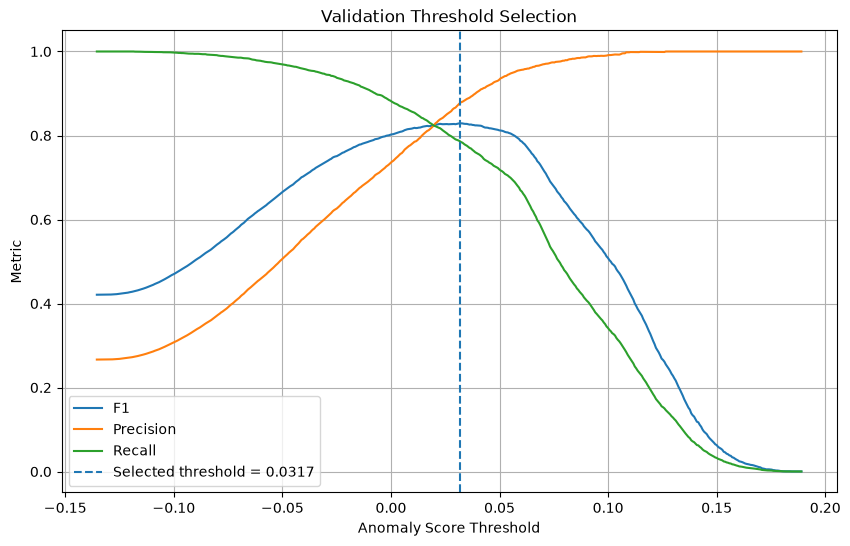

In [42]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1"],
    label="F1"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    label="Precision"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["recall"],
    label="Recall"
)

plt.axvline(
    validation_threshold,
    linestyle="--",
    label=f"Selected threshold = {validation_threshold:.4f}"
)

plt.xlabel("Anomaly Score Threshold")
plt.ylabel("Metric")
plt.title("Validation Threshold Selection")
plt.legend()
plt.grid(True)
plt.show()

In [43]:
val_predictions = (
    val_scores >= validation_threshold
).astype(int)

val_cm = confusion_matrix(
    y_val,
    val_predictions,
    labels=[0, 1]
)

print("Validation Confusion Matrix:")
print(val_cm)

tn, fp, fn, tp = val_cm.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

print("\nAccuracy:",
      accuracy_score(y_val, val_predictions))

print("Precision:",
      precision_score(y_val, val_predictions, zero_division=0))

print("Recall:",
      recall_score(y_val, val_predictions, zero_division=0))

print("F1:",
      f1_score(y_val, val_predictions, zero_division=0))

print("FPR:",
      fp / (fp + tn))

print("FNR:",
      fn / (fn + tp))

Validation Confusion Matrix:
[[14782   619]
 [ 1195  4404]]

TN: 14782
FP: 619
FN: 1195
TP: 4404

Accuracy: 0.9136190476190477
Precision: 0.8767668723870197
Recall: 0.7865690301839614
F1: 0.8292223686688006
FPR: 0.04019219531199273
FNR: 0.21343096981603857


In [44]:
# Freeze the threshold selected using validation data only.
frozen_threshold = validation_threshold

print("FROZEN THRESHOLD:", frozen_threshold)

FROZEN THRESHOLD: 0.03165348083041877


In [45]:
test_predictions = (
    test_scores >= frozen_threshold
).astype(int)

print("Test predictions generated.")
print("Number of test samples:", len(test_predictions))
print("Predicted normal:", np.sum(test_predictions == 0))
print("Predicted anomaly:", np.sum(test_predictions == 1))

Test predictions generated.
Number of test samples: 21000
Predicted normal: 15991
Predicted anomaly: 5009


In [46]:
test_cm = confusion_matrix(
    y_test,
    test_predictions,
    labels=[0, 1]
)

print("FINAL TEST CONFUSION MATRIX")
print(test_cm)

tn, fp, fn, tp = test_cm.ravel()

print("\nTN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

FINAL TEST CONFUSION MATRIX
[[14800   601]
 [ 1191  4408]]

TN: 14800
FP: 601
FN: 1191
TP: 4408


In [47]:
test_accuracy = accuracy_score(
    y_test,
    test_predictions
)

test_precision = precision_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_recall = recall_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    test_predictions,
    zero_division=0
)

test_fpr = (
    fp / (fp + tn)
    if (fp + tn) > 0
    else 0.0
)

test_fnr = (
    fn / (fn + tp)
    if (fn + tp) > 0
    else 0.0
)

test_roc_auc = roc_auc_score(
    y_test,
    test_scores
)

test_pr_auc = average_precision_score(
    y_test,
    test_scores
)

print("========== FINAL TEST METRICS ==========")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_roc_auc:.4f}")
print(f"PR-AUC   : {test_pr_auc:.4f}")
print(f"FPR      : {test_fpr:.4f}")
print(f"FNR      : {test_fnr:.4f}")

========== FINAL TEST METRICS ==========
Accuracy : 0.9147
Precision: 0.8800
Recall   : 0.7873
F1-score : 0.8311
ROC-AUC  : 0.9579
PR-AUC   : 0.9169
FPR      : 0.0390
FNR      : 0.2127


In [48]:
print("========== FINAL TEST CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=["Normal", "Anomaly"],
        digits=4,
        zero_division=0
    )
)

========== FINAL TEST CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

      Normal     0.9255    0.9610    0.9429     15401
     Anomaly     0.8800    0.7873    0.8311      5599

    accuracy                         0.9147     21000
   macro avg     0.9028    0.8741    0.8870     21000
weighted avg     0.9134    0.9147    0.9131     21000



In [49]:
print("========== TEST FAULT DISTRIBUTION ==========")

print(
    test_df["fault_type"].value_counts()
)

print("\n========== TEST FAULT MISSION DISTRIBUTION ==========")

test_fault_mission_summary = (
    test_df[
        test_df["fault_type"] != "normal"
    ]
    .groupby(
        ["mission_id", "fault_type"]
    )
    .size()
    .reset_index(name="samples")
)

print(
    test_fault_mission_summary.to_string(
        index=False
    )
)

========== TEST FAULT DISTRIBUTION ==========
fault_type
normal                     15401
injector_degradation        1708
lubrication_degradation     1708
overheating                  807
misfire                      712
sensor_fault                 664
Name: count, dtype: int64

========== TEST FAULT MISSION DISTRIBUTION ==========
 mission_id              fault_type  samples
         71    injector_degradation      854
         72    injector_degradation      854
         86 lubrication_degradation      854
         88 lubrication_degradation      854
         93             overheating      807
         97                 misfire      712
         99            sensor_fault      664


In [50]:
test_results = test_df[
    [
        "mission_id",
        "timestamp_s",
        "fault_type",
        "anomaly_label"
    ]
].copy()

test_results["anomaly_score"] = test_scores
test_results["prediction"] = test_predictions

print(test_results.head())

   mission_id  timestamp_s fault_type  anomaly_label  anomaly_score  \
0           1            0     normal              0      -0.080443   
1           1            1     normal              0      -0.111643   
2           1            2     normal              0      -0.116641   
3           1            3     normal              0      -0.059238   
4           1            4     normal              0      -0.079831   

   prediction  
0           0  
1           0  
2           0  
3           0  
4           0  


In [51]:
fault_types = [
    "injector_degradation",
    "lubrication_degradation",
    "overheating",
    "misfire",
    "sensor_fault"
]

faultwise_results = []

for fault_type in fault_types:

    fault_data = test_results[
        test_results["fault_type"] == fault_type
    ]

    total_samples = len(fault_data)

    detected = int(
        fault_data["prediction"].sum()
    )

    missed = total_samples - detected

    detection_rate = (
        detected / total_samples
        if total_samples > 0
        else 0.0
    )

    faultwise_results.append({
        "fault_type": fault_type,
        "samples": total_samples,
        "detected": detected,
        "missed": missed,
        "detection_rate": detection_rate
    })

faultwise_df = pd.DataFrame(
    faultwise_results
)

print(
    faultwise_df.to_string(index=False)
)

             fault_type  samples  detected  missed  detection_rate
   injector_degradation     1708      1562     146        0.914520
lubrication_degradation     1708      1329     379        0.778103
            overheating      807       775      32        0.960347
                misfire      712       456     256        0.640449
           sensor_fault      664       286     378        0.430723


In [52]:
faultwise_display = faultwise_df.copy()

faultwise_display["detection_rate_percent"] = (
    faultwise_display["detection_rate"] * 100
)

faultwise_display = faultwise_display[
    [
        "fault_type",
        "samples",
        "detected",
        "missed",
        "detection_rate_percent"
    ]
]

print(
    faultwise_display.to_string(index=False)
)

             fault_type  samples  detected  missed  detection_rate_percent
   injector_degradation     1708      1562     146               91.451991
lubrication_degradation     1708      1329     379               77.810304
            overheating      807       775      32               96.034696
                misfire      712       456     256               64.044944
           sensor_fault      664       286     378               43.072289


In [53]:
fault_score_summary = (
    test_results
    .groupby("fault_type")["anomaly_score"]
    .describe()
)

print(
    fault_score_summary.to_string()
)

                           count      mean       std       min       25%       50%       75%       max
fault_type                                                                                            
injector_degradation      1708.0  0.109952  0.045535 -0.096085  0.104028  0.120487  0.137515  0.179664
lubrication_degradation   1708.0  0.050385  0.046849 -0.120837  0.041840  0.067234  0.078249  0.134135
misfire                    712.0  0.047981  0.057468 -0.099292 -0.001384  0.059815  0.094954  0.152608
normal                   15401.0 -0.061459  0.043768 -0.134775 -0.095145 -0.070617 -0.036096  0.146844
overheating                807.0  0.093406  0.032097 -0.050114  0.074795  0.097403  0.116655  0.167456
sensor_fault               664.0  0.027429  0.024742 -0.052711  0.009501  0.027469  0.043578  0.113342


In [54]:
fault_mission_detection = (
    test_results[
        test_results["fault_type"] != "normal"
    ]
    .groupby(
        ["mission_id", "fault_type"]
    )
    .agg(
        samples=("prediction", "size"),
        detected=("prediction", "sum")
    )
    .reset_index()
)

fault_mission_detection["missed"] = (
    fault_mission_detection["samples"]
    - fault_mission_detection["detected"]
)

fault_mission_detection["detection_rate"] = (
    fault_mission_detection["detected"]
    / fault_mission_detection["samples"]
)

print(
    fault_mission_detection.to_string(index=False)
)

 mission_id              fault_type  samples  detected  missed  detection_rate
         71    injector_degradation      854       780      74        0.913349
         72    injector_degradation      854       782      72        0.915691
         86 lubrication_degradation      854       663     191        0.776347
         88 lubrication_degradation      854       666     188        0.779859
         93             overheating      807       775      32        0.960347
         97                 misfire      712       456     256        0.640449
         99            sensor_fault      664       286     378        0.430723


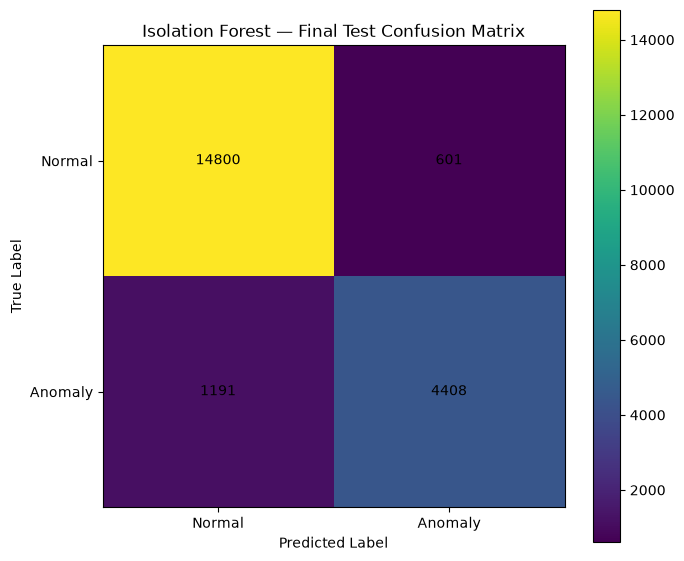

In [55]:
plt.figure(figsize=(7, 6))

plt.imshow(test_cm)

plt.title("Isolation Forest — Final Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(
    [0, 1],
    ["Normal", "Anomaly"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Anomaly"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            test_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

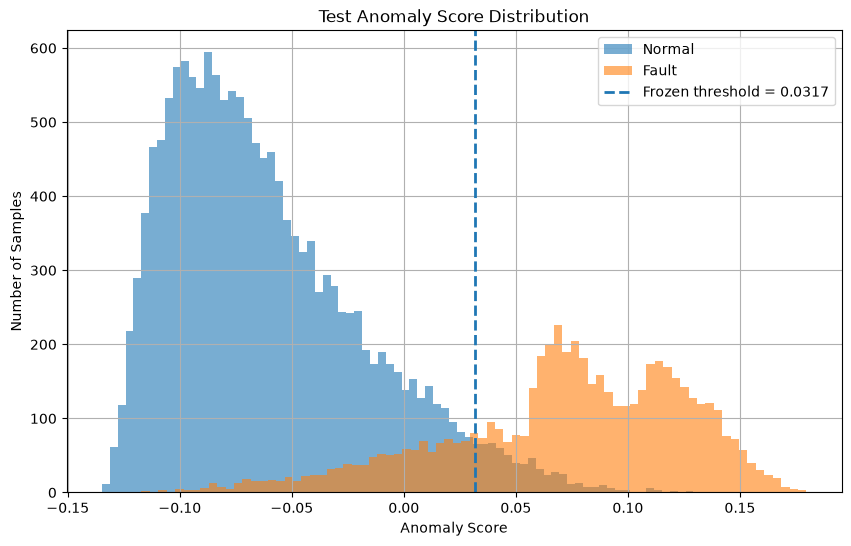

In [56]:
normal_scores = test_results[
    test_results["anomaly_label"] == 0
]["anomaly_score"]

fault_scores = test_results[
    test_results["anomaly_label"] == 1
]["anomaly_score"]

plt.figure(figsize=(10, 6))

plt.hist(
    normal_scores,
    bins=80,
    alpha=0.6,
    label="Normal"
)

plt.hist(
    fault_scores,
    bins=80,
    alpha=0.6,
    label="Fault"
)

plt.axvline(
    frozen_threshold,
    linestyle="--",
    linewidth=2,
    label=f"Frozen threshold = {frozen_threshold:.4f}"
)

plt.xlabel("Anomaly Score")
plt.ylabel("Number of Samples")
plt.title("Test Anomaly Score Distribution")
plt.legend()
plt.grid(True)
plt.show()

In [57]:
def create_realtime_features(current_sample, feature_cols):
    """
    Create the exact feature representation required by the trained model
    from one raw engine sensor sample.
    """

    sample = pd.Series(current_sample).copy()

    required_raw_columns = [
        "cht_C",
        "expected_cht_C",
        "egt_C",
        "expected_egt_C",
        "rpm",
        "expected_rpm",
        "oil_temperature_C",
        "oil_pressure_bar",
        "vibration_rms",
        "battery_voltage_V",
        "alternator_current_A",
        "alternator_health",
        "injection_timing_deg",
        "physics_residual_C"
    ]

    missing_columns = [
        column
        for column in required_raw_columns
        if column not in sample.index
    ]

    if missing_columns:
        raise ValueError(
            f"Missing required input columns: {missing_columns}"
        )

    # Recreate the physics-derived residuals exactly as during training.
    sample["cht_residual"] = (
        sample["cht_C"] - sample["expected_cht_C"]
    )

    sample["egt_residual"] = (
        sample["egt_C"] - sample["expected_egt_C"]
    )

    sample["rpm_residual"] = (
        sample["rpm"] - sample["expected_rpm"]
    )

    feature_vector = sample[feature_cols].astype(float)

    if feature_vector.isna().any():
        raise ValueError(
            "The realtime feature vector contains missing values."
        )

    return feature_vector

In [58]:
def predict_realtime(
    current_sample,
    scaler,
    iso_forest,
    threshold,
    feature_cols
):
    """
    Perform single-sample anomaly detection.

    Returns:
        anomaly_score
        prediction
    """

    # Create the same 13-feature representation used during training
    feature_vector = create_realtime_features(
        current_sample,
        feature_cols
    )

    # Keep feature names because StandardScaler was fitted
    # using a DataFrame with these same feature names.
    feature_dataframe = pd.DataFrame(
        [feature_vector],
        columns=feature_cols
    )

    # Apply the already-fitted scaler.
    scaled_features = scaler.transform(
        feature_dataframe
    )

    # Get Isolation Forest decision function.
    decision_value = iso_forest.decision_function(
        scaled_features
    )[0]

    # Our convention:
    # higher anomaly_score = more anomalous
    anomaly_score = -decision_value

    # Apply the FROZEN validation threshold.
    prediction = int(
        anomaly_score >= threshold
    )

    return {
        "anomaly_score": float(anomaly_score),
        "prediction": prediction
    }

In [59]:
first_test_sample = test_df.iloc[0]

realtime_output = predict_realtime(
    current_sample=first_test_sample,
    scaler=scaler,
    iso_forest=iso_forest,
    threshold=frozen_threshold,
    feature_cols=feature_cols
)

print("Single-sample realtime output:")
print(realtime_output)

Single-sample realtime output:
{'anomaly_score': -0.08044291563308437, 'prediction': 0}


In [60]:
first_test_index = test_df.index[0]

batch_score = float(
    test_results.loc[
        first_test_index,
        "anomaly_score"
    ]
)

batch_prediction = int(
    test_results.loc[
        first_test_index,
        "prediction"
    ]
)

realtime_score = realtime_output["anomaly_score"]
realtime_prediction = realtime_output["prediction"]

print("========== BATCH VS REALTIME ==========")

print(
    "Batch anomaly score:    ",
    batch_score
)

print(
    "Realtime anomaly score: ",
    realtime_score
)

print(
    "\nBatch prediction:       ",
    batch_prediction
)

print(
    "Realtime prediction:    ",
    realtime_prediction
)

print(
    "\nScore difference:",
    abs(batch_score - realtime_score)
)

print(
    "Prediction match:",
    batch_prediction == realtime_prediction
)

========== BATCH VS REALTIME ==========
Batch anomaly score:     -0.08044291563308437
Realtime anomaly score:  -0.08044291563308437

Batch prediction:        0
Realtime prediction:     0

Score difference: 0.0
Prediction match: True


In [61]:
def create_temporal_state():
    """
    Create a fresh temporal state for one mission.
    """

    return {
        "consecutive_anomalies": 0,
        "status": "NORMAL"
    }

In [62]:
def update_temporal_state(
    instantaneous_prediction,
    state,
    confirmation_length=5
):
    """
    Update temporal anomaly-confirmation state.

    States:
        NORMAL
        WARNING
        CONFIRMED ANOMALY
    """

    if instantaneous_prediction == 0:

        # A normal sample resets the consecutive-anomaly counter.
        state["consecutive_anomalies"] = 0
        state["status"] = "NORMAL"

    else:

        # Another consecutive anomaly.
        state["consecutive_anomalies"] += 1

        if (
            state["consecutive_anomalies"]
            >= confirmation_length
        ):
            state["status"] = "CONFIRMED ANOMALY"

        else:
            state["status"] = "WARNING"

    return state

In [63]:
temporal_state = create_temporal_state()

test_sequence = [
    0,
    1,
    1,
    1,
    1,
    1,
    1,
    0,
    1
]

print("========== TEMPORAL STATE TEST ==========")

for prediction in test_sequence:

    temporal_state = update_temporal_state(
        instantaneous_prediction=prediction,
        state=temporal_state,
        confirmation_length=5
    )

    print(
        f"Prediction={prediction} | "
        f"Consecutive={temporal_state['consecutive_anomalies']} | "
        f"Status={temporal_state['status']}"
    )

========== TEMPORAL STATE TEST ==========
Prediction=0 | Consecutive=0 | Status=NORMAL
Prediction=1 | Consecutive=1 | Status=WARNING
Prediction=1 | Consecutive=2 | Status=WARNING
Prediction=1 | Consecutive=3 | Status=WARNING
Prediction=1 | Consecutive=4 | Status=WARNING
Prediction=1 | Consecutive=5 | Status=CONFIRMED ANOMALY
Prediction=1 | Consecutive=6 | Status=CONFIRMED ANOMALY
Prediction=0 | Consecutive=0 | Status=NORMAL
Prediction=1 | Consecutive=1 | Status=WARNING


In [64]:
test_sequential_df = test_df.sort_values(
    ["mission_id", "timestamp_s"]
).copy()

print("Chronological test data:")
print(
    test_sequential_df[
        [
            "mission_id",
            "timestamp_s",
            "fault_type"
        ]
    ].head(20).to_string(index=False)
)

Chronological test data:
 mission_id  timestamp_s fault_type
          1            0     normal
          1            1     normal
          1            2     normal
          1            3     normal
          1            4     normal
          1            5     normal
          1            6     normal
          1            7     normal
          1            8     normal
          1            9     normal
          1           10     normal
          1           11     normal
          1           12     normal
          1           13     normal
          1           14     normal
          1           15     normal
          1           16     normal
          1           17     normal
          1           18     normal
          1           19     normal


In [65]:
time_order_valid = True

for mission_id, mission_data in test_sequential_df.groupby(
    "mission_id"
):

    timestamps = mission_data["timestamp_s"].to_numpy()

    if not np.all(
        np.diff(timestamps) >= 0
    ):
        time_order_valid = False

        print(
            f"Timestamp ordering problem "
            f"in mission {mission_id}"
        )

if time_order_valid:
    print(
        "PASS: Test samples are chronologically "
        "ordered within every mission."
    )

PASS: Test samples are chronologically ordered within every mission.


In [66]:
# ============================================================
# CELL 48B — EFFICIENT TEMPORAL SIMULATION
# ============================================================

realtime_results_df = test_sequential_df[
    [
        "mission_id",
        "timestamp_s"
    ]
].copy()

# Use the already-generated test scores and predictions.
realtime_results_df["anomaly_score"] = (
    test_results.set_index(
        ["mission_id", "timestamp_s"]
    )
    .loc[
        realtime_results_df[
            ["mission_id", "timestamp_s"]
        ].apply(tuple, axis=1)
    ]["anomaly_score"]
    .to_numpy()
)

realtime_results_df["instantaneous_prediction"] = (
    realtime_results_df["anomaly_score"]
    >= frozen_threshold
).astype(int)

# ------------------------------------------------------------
# Apply temporal confirmation mission-by-mission.
# ------------------------------------------------------------

temporal_statuses = []
consecutive_counts = []

for mission_id, mission_data in (
    realtime_results_df.groupby(
        "mission_id",
        sort=False
    )
):

    consecutive = 0

    for prediction in mission_data[
        "instantaneous_prediction"
    ]:

        if prediction == 0:
            consecutive = 0
            status = "NORMAL"

        else:
            consecutive += 1

            if consecutive >= 5:
                status = "CONFIRMED ANOMALY"
            else:
                status = "WARNING"

        consecutive_counts.append(consecutive)
        temporal_statuses.append(status)


realtime_results_df["consecutive_anomalies"] = (
    consecutive_counts
)

realtime_results_df["temporal_status"] = (
    temporal_statuses
)

print("Realtime temporal simulation completed.")

print(
    "Number of processed samples:",
    len(realtime_results_df)
)

print("\nFirst 20 results:")

print(
    realtime_results_df.head(20).to_string(index=False)
)

Realtime temporal simulation completed.
Number of processed samples: 21000

First 20 results:
 mission_id  timestamp_s  anomaly_score  instantaneous_prediction  consecutive_anomalies temporal_status
          1            0      -0.080443                         0                      0          NORMAL
          1            1      -0.111643                         0                      0          NORMAL
          1            2      -0.116641                         0                      0          NORMAL
          1            3      -0.059238                         0                      0          NORMAL
          1            4      -0.079831                         0                      0          NORMAL
          1            5      -0.091920                         0                      0          NORMAL
          1            6      -0.015202                         0                      0          NORMAL
          1            7      -0.093885                         0 

In [67]:
# ============================================================
# CELL 49 — BATCH VS REALTIME COMPARISON
# ============================================================

batch_reference = test_results[
    [
        "mission_id",
        "timestamp_s",
        "anomaly_score",
        "prediction"
    ]
].copy()

batch_reference = batch_reference.rename(
    columns={
        "anomaly_score": "batch_anomaly_score",
        "prediction": "batch_prediction"
    }
)

comparison_df = realtime_results_df.merge(
    batch_reference,
    on=[
        "mission_id",
        "timestamp_s"
    ],
    how="left"
)

comparison_df["score_difference"] = (
    comparison_df["anomaly_score"]
    - comparison_df["batch_anomaly_score"]
).abs()

comparison_df["prediction_match"] = (
    comparison_df["instantaneous_prediction"]
    == comparison_df["batch_prediction"]
)

print("========== BATCH VS REALTIME ==========")

print(
    comparison_df[
        [
            "mission_id",
            "timestamp_s",
            "anomaly_score",
            "batch_anomaly_score",
            "score_difference",
            "instantaneous_prediction",
            "batch_prediction",
            "prediction_match"
        ]
    ].head(20).to_string(index=False)
)

========== BATCH VS REALTIME ==========
 mission_id  timestamp_s  anomaly_score  batch_anomaly_score  score_difference  instantaneous_prediction  batch_prediction  prediction_match
          1            0      -0.080443            -0.080443               0.0                         0                 0              True
          1            1      -0.111643            -0.111643               0.0                         0                 0              True
          1            2      -0.116641            -0.116641               0.0                         0                 0              True
          1            3      -0.059238            -0.059238               0.0                         0                 0              True
          1            4      -0.079831            -0.079831               0.0                         0                 0              True
          1            5      -0.091920            -0.091920               0.0                         0          

In [68]:
# ============================================================
# CELL 50 — FINAL CONSISTENCY CHECK
# ============================================================

max_score_difference = (
    comparison_df["score_difference"].max()
)

mean_score_difference = (
    comparison_df["score_difference"].mean()
)

prediction_mismatches = (
    (~comparison_df["prediction_match"]).sum()
)

print("========== BATCH VS REALTIME CONSISTENCY ==========")

print(
    "Maximum score difference:",
    max_score_difference
)

print(
    "Mean score difference:",
    mean_score_difference
)

print(
    "Instantaneous prediction mismatches:",
    prediction_mismatches
)

if (
    max_score_difference < 1e-10
    and prediction_mismatches == 0
):

    print(
        "\nPASS: Realtime inference matches "
        "batch inference."
    )

else:

    print(
        "\nWARNING: Realtime and batch inference "
        "do not match exactly."
    )

========== BATCH VS REALTIME CONSISTENCY ==========
Maximum score difference: 0.0
Mean score difference: 0.0
Instantaneous prediction mismatches: 0

PASS: Realtime inference matches batch inference.


In [69]:
# ============================================================
# CELL 51 — TEMPORAL STATUS COUNTS
# ============================================================

print("========== TEMPORAL STATUS COUNTS ==========")

status_counts = (
    realtime_results_df[
        "temporal_status"
    ]
    .value_counts()
)

print(status_counts)

========== TEMPORAL STATUS COUNTS ==========
temporal_status
NORMAL               15991
CONFIRMED ANOMALY     3673
WARNING               1336
Name: count, dtype: int64


In [70]:
# ============================================================
# CELL 52 — CONFIRMED ANOMALIES BY MISSION
# ============================================================

print(
    "========== CONFIRMED ANOMALIES BY MISSION =========="
)

confirmed_by_mission = (
    realtime_results_df[
        realtime_results_df["temporal_status"]
        == "CONFIRMED ANOMALY"
    ]
    .groupby("mission_id")
    .size()
    .sort_index()
)

print(confirmed_by_mission)

========== CONFIRMED ANOMALIES BY MISSION ==========
mission_id
31      4
35      9
68     19
71    719
72    724
86    536
88    536
93    713
97    323
99     90
dtype: int64


In [71]:
# ============================================================
# CELL 53 — FIRST CONFIRMED ANOMALY
# ============================================================

first_confirmed = (
    realtime_results_df[
        realtime_results_df["temporal_status"]
        == "CONFIRMED ANOMALY"
    ]
    .groupby("mission_id")
    .first()
    .reset_index()
)

print(
    "========== FIRST CONFIRMED ANOMALY =========="
)

if len(first_confirmed) > 0:

    print(
        first_confirmed[
            [
                "mission_id",
                "timestamp_s",
                "anomaly_score",
                "consecutive_anomalies"
            ]
        ].to_string(index=False)
    )

else:

    print(
        "No confirmed anomalies found."
    )

========== FIRST CONFIRMED ANOMALY ==========
 mission_id  timestamp_s  anomaly_score  consecutive_anomalies
         31          713       0.035896                      5
         35          905       0.071415                      5
         68           26       0.108166                      5
         71          219       0.032385                      5
         72          235       0.097434                      5
         86          358       0.065299                      5
         88          373       0.071084                      5
         93          232       0.066347                      5
         97          487       0.039227                      5
         99          679       0.048388                      5


In [72]:
# ============================================================
# CELL 54 — TEMPORAL RESULTS BY FAULT TYPE
# ============================================================

temporal_fault_results = realtime_results_df.merge(
    test_df[
        [
            "mission_id",
            "timestamp_s",
            "fault_type",
            "anomaly_label"
        ]
    ],
    on=[
        "mission_id",
        "timestamp_s"
    ],
    how="left"
)

print(
    "========== TEMPORAL RESULTS BY FAULT TYPE =========="
)

temporal_fault_summary = (
    temporal_fault_results
    .groupby("fault_type")
    .agg(
        samples=("temporal_status", "size"),

        confirmed=(
            "temporal_status",
            lambda x: (
                x == "CONFIRMED ANOMALY"
            ).sum()
        ),

        warning=(
            "temporal_status",
            lambda x: (
                x == "WARNING"
            ).sum()
        ),

        normal=(
            "temporal_status",
            lambda x: (
                x == "NORMAL"
            ).sum()
        )
    )
)

print(
    temporal_fault_summary.to_string()
)

========== TEMPORAL RESULTS BY FAULT TYPE ==========
                         samples  confirmed  warning  normal
fault_type                                                  
injector_degradation        1708       1443      119     146
lubrication_degradation     1708       1072      257     379
misfire                      712        323      133     256
normal                     15401         32      569   14800
overheating                  807        713       62      32
sensor_fault                 664         90      196     378
